
# Implementação e Avaliação do FixMatch com CIFAR-10

### Objetivo
Neste assignment, vocês implementarão o método FixMatch, uma técnica de aprendizado semi-supervisionado que combina aprendizado supervisionado e não supervisionado. O objetivo é aplicar o FixMatch ao dataset CIFAR-10 para treinar uma rede neural e avaliar os resultados obtidos com diferentes proporções de dados rotulados.

### 1. Introdução ao FixMatch
FixMatch é uma técnica que combina pseudo-rotulagem e consistência de dados aumentados. Em resumo, o método:
- **Gera pseudo-rótulos** para dados não rotulados, utilizando uma predição confiável de dados fracamente aumentados.
- **Aplica uma consistência de pseudo-rótulos**, onde a rede é treinada para produzir as mesmas previsões em versões fortemente aumentadas das mesmas imagens.

Para mais informações sobre a arquitetura e a metodologia do FixMatch, vocês podem consultar o [paper original](https://arxiv.org/abs/2001.07685) e/ou ver os slides disponibilizados.

### 2. Estrutura da Implementação

1. **Dataset e Preparação dos Dados**  
   - Use o CIFAR-10 como dataset.
   - Prepare duas versões dos dados:
     - **Dados rotulados:** Utilizem um subconjunto rotulado do CIFAR-10 com diferentes quantidades de rótulos por classe para experimentação.
     - **Dados não rotulados:** O restante do CIFAR-10 deve ser usado como dados não rotulados.

2. **Modelo Base**  
   - Utilize um modelo de CNN simples ou uma arquitetura pré-definida (sugestão: ResNet-18) para a implementação.

3. **Implementação do FixMatch**
   - **Pseudo-rotulagem:** Implemente a geração de rótulos para os dados não rotulados usando predições de confiança de uma versão levemente aumentada da imagem.
   - **Consistência de Augmentation:** Aplique uma versão fortemente aumentada da imagem e treine a rede para manter consistência nos pseudo-rótulos.
   - **Função de Perda**:
     - O FixMatch utiliza uma função de perda híbrida, combinando a perda supervisionada e a não supervisionada:
       - **Perda Supervisionada:** Aplique a entropia cruzada entre os rótulos reais e as predições do modelo para os dados rotulados.
       - **Perda Não Supervisionada (Consistência de Pseudo-rótulos):** Para os dados não rotulados, aplique uma entropia cruzada entre os pseudo-rótulos e as previsões das imagens aumentadas, incluindo apenas as amostras com confiança acima de um limite predefinido (threshold).
       - A função de perda final é a soma ponderada das perdas supervisionada e não supervisionada.

   - **Detalhes Importantes nas Seções 2.3 e 2.4 do paper**;

4. **Treinamento e Otimização**

### 3. Experimentos e Análise

Para avaliar o desempenho do FixMatch, vocês devem realizar experimentos com diferentes quantidades de dados rotulados. Especificamente, testem com:

1. **1 rótulo por classe** (total de 10 rótulos): Este experimento extremo explora o desempenho do FixMatch com uma quantidade mínima de dados rotulados. Observem a eficácia da técnica de pseudo-rotulagem nesse cenário.

2. **4 rótulos por classe** (total de 40 rótulos): Com um conjunto pequeno, analisem o desempenho da rede com algumas amostras rotuladas e o impacto dos pseudo-rótulos.

3. **25 rótulos por classe** (total de 250 rótulos): Esse experimento permitirá uma análise mais profunda da eficácia do FixMatch em cenários com uma quantidade moderada de rótulos.

4. **400 rótulos por classe** (total de 4.000 rótulos): Avaliem o desempenho do modelo com um conjunto mais substancial de dados rotulados, investigando o impacto da quantidade crescente de rótulos.

**Proponha pelo menos mais algum teste, fundamente sua escolha e discuta os resultados.**

Para cada experimento:
   - Treine o modelo e avalie a acurácia nos dados de teste.
   - Documente os resultados e compare a eficácia do FixMatch com a quantidade de dados rotulados disponíveis.
   - Analise o impacto dos pseudo-rótulos na qualidade do modelo, principalmente nos cenários com poucos rótulos (1, 4 e 25 rótulos por classe).

### 4. Apresentação
No final, vocês devem preparar e apresentar:

1. Slides de apresentação ou relatório:
- Explicação da implementação de cada parte do FixMatch. (simples e rápida)
- Resultados e gráficos das avaliações para os quatro cenários de rótulos por classe. (Importante)
- Análise sobre o impacto da quantidade de dados rotulados, a função de perda híbrida, e o efeito dos thresholds e data augmentation. (Importante)

2. Apresentação de 10-15 minutos
- Grave uma apresentação do seu slide/relatório cobrindo todos os pontos pedidos.

*Note que a apresentação e o conteúdo dos slides deve cobrir todos os requisitos solicitados, pois sua avaliação vai depender 90% da apresentação. 



In [1]:
!pip install torch torchvision tqdm matplotlib --quiet

import os, random, copy, math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader, Dataset, Subset
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 104.1 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 78.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 30.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 3.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 53.2 MB/s eta 0:00:0000:0100:01m
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed

### Preparação de dados

In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(1)

def make_labeled_unlabeled_split(dataset, n_per_class, num_classes=10, seed=42):
    rng = np.random.RandomState(seed)
    labels = np.array(dataset.targets)
    labeled_idx, unlabeled_idx = [], []
    for c in range(num_classes):
        idx = np.where(labels == c)[0]
        rng.shuffle(idx)
        labeled_idx += idx[:n_per_class].tolist()
        unlabeled_idx += idx[n_per_class:].tolist()
    rng.shuffle(labeled_idx)
    rng.shuffle(unlabeled_idx)
    return labeled_idx, unlabeled_idx


### Augmentations

In [3]:
weak_tf = T.Compose([
    T.RandomHorizontalFlip(),
    T.RandomCrop(32, padding=4),
    T.ToTensor(),
    T.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))
])

try:
    from torchvision.transforms import RandAugment
    strong_tf = T.Compose([
        T.RandomHorizontalFlip(),
        T.RandomCrop(32, padding=4),
        RandAugment(num_ops=2, magnitude=9),
        T.ToTensor(),
        T.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))
    ])
except:
    strong_tf = T.Compose([
        T.RandomHorizontalFlip(),
        T.RandomCrop(32, padding=4),
        T.ColorJitter(0.4,0.4,0.4,0.1),
        T.RandomGrayscale(p=0.2),
        T.ToTensor(),
        T.Normalize((0.4914,0.4822,0.4465),(0.247,0.243,0.261))
    ])

test_tf = T.Compose([
    T.ToTensor(),
    T.Normalize((0.4914,0.4822,0.4465),(0.247,0.243,0.261))
])


In [4]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device:", device)

base_train = torchvision.datasets.CIFAR10(root='./data', train=True, download=True)
test_set = torchvision.datasets.CIFAR10(root='./data', train=False, transform=test_tf, download=True)

# Exemplo: 4 rótulos por classe
labeled_idx, unlabeled_idx = make_labeled_unlabeled_split(base_train, 4)

labeled_dataset = copy.deepcopy(base_train)
labeled_dataset.transform = weak_tf
labeled_subset = Subset(labeled_dataset, labeled_idx)

class UnlabeledDataset(Dataset):
    def __init__(self, base, idxs, weak_tf, strong_tf):
        self.base, self.idxs = base, idxs
        self.weak_tf, self.strong_tf = weak_tf, strong_tf
    def __len__(self): return len(self.idxs)
    def __getitem__(self, i):
        from PIL import Image
        x, _ = self.base[self.idxs[i]]
        pil = x if isinstance(x, Image.Image) else Image.fromarray(x)
        return self.weak_tf(pil), self.strong_tf(pil)

unlabeled_dataset = UnlabeledDataset(base_train, unlabeled_idx, weak_tf, strong_tf)

labeled_loader = DataLoader(labeled_subset, batch_size=64, shuffle=True, num_workers=2, drop_last=False)
unlabeled_loader = DataLoader(unlabeled_dataset, batch_size=320, shuffle=True, num_workers=2, drop_last=True)
test_loader = DataLoader(test_set, batch_size=256, shuffle=False, num_workers=2)


Device: cuda


100%|██████████| 170M/170M [00:03<00:00, 53.5MB/s] 


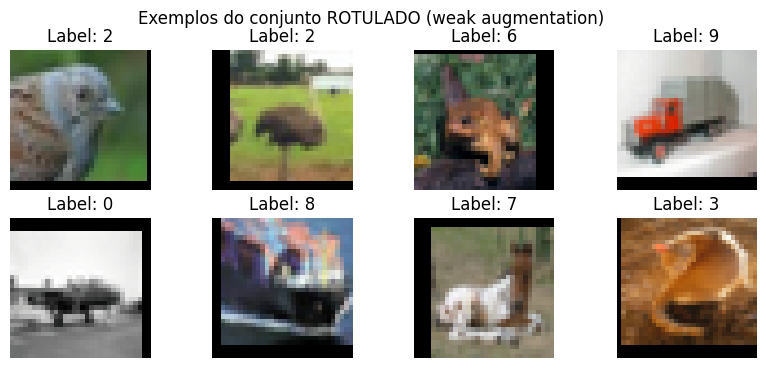

In [5]:
# Função para reverter a normalização (para visualização correta)
def denormalize(img_tensor):
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.247, 0.243, 0.261])
    img = img_tensor.permute(1, 2, 0).cpu().numpy()
    img = std * img + mean
    img = np.clip(img, 0, 1)
    return img

# Carregar alguns exemplos do conjunto rotulado
images, labels = next(iter(labeled_loader))

plt.figure(figsize=(10, 4))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(denormalize(images[i]))
    plt.title(f"Label: {labels[i].item()}")
    plt.axis("off")
plt.suptitle("Exemplos do conjunto ROTULADO (weak augmentation)")
plt.show()


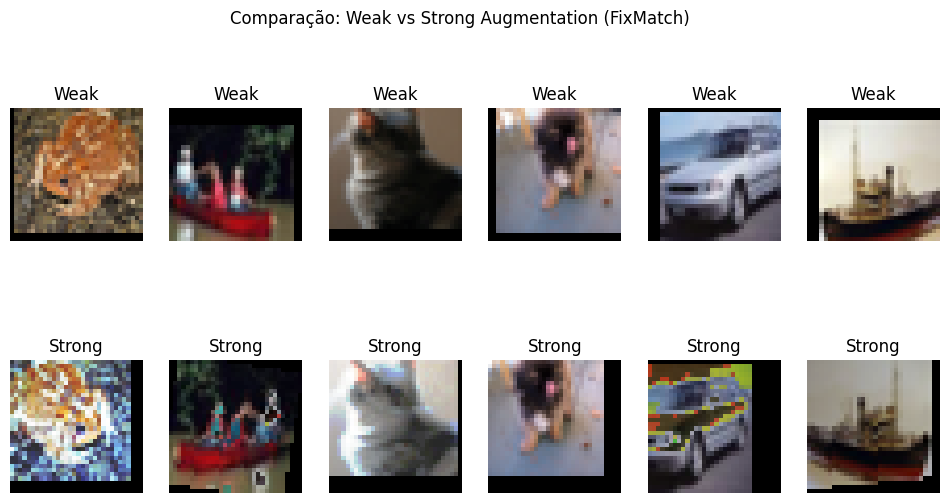

In [6]:
u_w, u_s = next(iter(unlabeled_loader))

plt.figure(figsize=(12, 6))
for i in range(6):
    # weak
    plt.subplot(2, 6, i + 1)
    plt.imshow(denormalize(u_w[i]))
    plt.title("Weak")
    plt.axis("off")

    # strong
    plt.subplot(2, 6, i + 7)
    plt.imshow(denormalize(u_s[i]))
    plt.title("Strong")
    plt.axis("off")

plt.suptitle("Comparação: Weak vs Strong Augmentation (FixMatch)")
plt.show()


### Modelo (ResNet-18 ou Wide ResNet)

In [9]:
def get_model(num_classes=10, tipo = "resnet"):
    if tipo == "resnet":
        model = torchvision.models.resnet18(pretrained=False)
    elif tipo == "WideResnet":
        model = torch.hub.load('pytorch/vision:v0.10.0', 'wide_resnet50_2', pretrained=False)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


### Funções de treino e avaliação

In [10]:
def train_fixmatch(model, device, labeled_loader, unlabeled_loader, optimizer, epoch, lambda_u, threshold):
    model.train()
    criterion = nn.CrossEntropyLoss()
    unlabeled_iter = iter(unlabeled_loader)
    total_loss, total_sup, total_unsup = 0, 0, 0

    for batch_idx, (x_l, y_l) in enumerate(tqdm(labeled_loader, desc=f"Epoch {epoch}")):
        try:
            (u_w, u_s) = next(unlabeled_iter)
        except StopIteration:
            unlabeled_iter = iter(unlabeled_loader)
            (u_w, u_s) = next(unlabeled_iter)

        x_l, y_l = x_l.to(device), y_l.to(device)
        u_w, u_s = u_w.to(device), u_s.to(device)

        logits_x = model(x_l)
        Lx = criterion(logits_x, y_l)

        with torch.no_grad():
            p = torch.softmax(model(u_w), dim=1)
            max_p, pseudo = torch.max(p, dim=1)
            mask = max_p.ge(threshold).float()

        logits_u_s = model(u_s)
        Lu = (F.cross_entropy(logits_u_s, pseudo, reduction='none') * mask).sum() / (mask.sum() + 1e-8)
        # Lu = (F.cross_entropy(logits_u_s, pseudo, reduction='none') * mask).mean()

        loss = Lx + lambda_u * Lu
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item(); total_sup += Lx.item(); total_unsup += Lu.item()
    return total_loss / len(labeled_loader)

def evaluate(model, device, test_loader):
    model.eval()
    correct = 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            preds = model(x).argmax(dim=1)
            correct += (preds == y).sum().item()
    return correct / len(test_loader.dataset)


Preparação dos dados e experimento

## Treino com resnet

In [ ]:
# Exemplo: 1 rótulo por classe

qtd_epochs = 50
labeled_idx, unlabeled_idx = make_labeled_unlabeled_split(base_train, 1)

labeled_dataset = copy.deepcopy(base_train)
labeled_dataset.transform = weak_tf
labeled_subset = Subset(labeled_dataset, labeled_idx)

unlabeled_dataset = UnlabeledDataset(base_train, unlabeled_idx, weak_tf, strong_tf)

labeled_loader = DataLoader(labeled_subset, batch_size=64, shuffle=True, num_workers=2, drop_last=False)
unlabeled_loader = DataLoader(unlabeled_dataset, batch_size=320, shuffle=True, num_workers=2, drop_last=True)
test_loader = DataLoader(test_set, batch_size=256, shuffle=False, num_workers=2)


model = get_model(tipo = "resnet").to(device)
optimizer = optim.SGD(model.parameters(), lr=0.003, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=qtd_epochs)

train_loss_hist, acc_hist = [], []

for epoch in range(1, qtd_epochs):
    loss = train_fixmatch(model, device, labeled_loader, unlabeled_loader, optimizer, epoch, lambda_u=1.0, threshold=0.8)
    acc = evaluate(model, device, test_loader)
    scheduler.step()
    train_loss_hist.append(loss)
    acc_hist.append(acc)
    print(f"Epoch {epoch:03d} | Loss: {loss:.3f} | Test Acc: {acc*100:.2f}%")


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
Epoch 1: 100%|██████████| 1/1 [00:01<00:00,  1.51s/it]


Epoch 001 | Loss: 2.419 | Test Acc: 12.56%


Epoch 2: 100%|██████████| 1/1 [00:00<00:00,  1.53it/s]


Epoch 002 | Loss: 2.359 | Test Acc: 11.28%


Epoch 3: 100%|██████████| 1/1 [00:00<00:00,  1.52it/s]


...

Epoch 047 | Loss: 1.218 | Test Acc: 14.54%


Epoch 48: 100%|██████████| 1/1 [00:00<00:00,  1.55it/s]


Epoch 048 | Loss: 1.246 | Test Acc: 14.57%


Epoch 49: 100%|██████████| 1/1 [00:00<00:00,  1.60it/s]


Epoch 049 | Loss: 1.137 | Test Acc: 14.54%


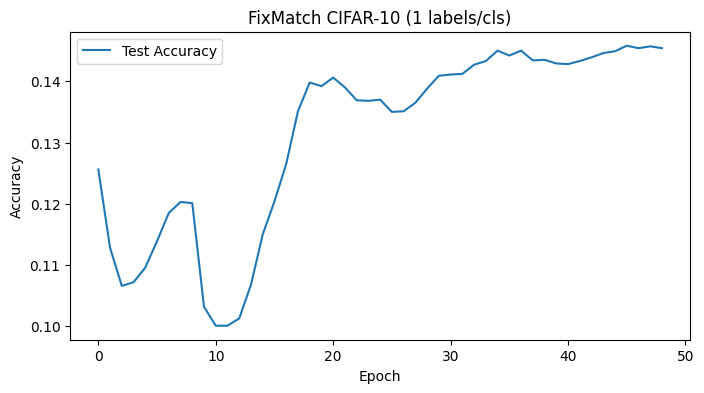

In [12]:
plt.figure(figsize=(8,4))
plt.plot(acc_hist, label='Test Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("FixMatch CIFAR-10 (1 labels/cls)")
plt.legend()
plt.show()


In [ ]:
# Exemplo: 4 rótulos por classe

qtd_epochs = 50
labeled_idx, unlabeled_idx = make_labeled_unlabeled_split(base_train, 4)

labeled_dataset = copy.deepcopy(base_train)
labeled_dataset.transform = weak_tf
labeled_subset = Subset(labeled_dataset, labeled_idx)

unlabeled_dataset = UnlabeledDataset(base_train, unlabeled_idx, weak_tf, strong_tf)

labeled_loader = DataLoader(labeled_subset, batch_size=64, shuffle=True, num_workers=2, drop_last=False)
unlabeled_loader = DataLoader(unlabeled_dataset, batch_size=320, shuffle=True, num_workers=2, drop_last=True)
test_loader = DataLoader(test_set, batch_size=256, shuffle=False, num_workers=2)


model = get_model(tipo = "resnet").to(device)
optimizer = optim.SGD(model.parameters(), lr=0.003, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=qtd_epochs)

train_loss_hist, acc_hist = [], []

for epoch in range(1, qtd_epochs):
    loss = train_fixmatch(model, device, labeled_loader, unlabeled_loader, optimizer, epoch, lambda_u=1.0, threshold=0.8)
    acc = evaluate(model, device, test_loader)
    scheduler.step()
    train_loss_hist.append(loss)
    acc_hist.append(acc)
    print(f"Epoch {epoch:03d} | Loss: {loss:.3f} | Test Acc: {acc*100:.2f}%")


Epoch 1: 100%|██████████| 1/1 [00:00<00:00,  1.49it/s]


Epoch 001 | Loss: 2.379 | Test Acc: 10.52%


Epoch 2: 100%|██████████| 1/1 [00:00<00:00,  1.51it/s]


Epoch 002 | Loss: 2.351 | Test Acc: 12.70%


Epoch 3: 100%|██████████| 1/1 [00:00<00:00,  1.47it/s]


...

Epoch 047 | Loss: 2.147 | Test Acc: 14.96%


Epoch 48: 100%|██████████| 1/1 [00:00<00:00,  1.31it/s]


Epoch 048 | Loss: 2.243 | Test Acc: 15.03%


Epoch 49: 100%|██████████| 1/1 [00:00<00:00,  1.50it/s]


Epoch 049 | Loss: 2.162 | Test Acc: 15.05%


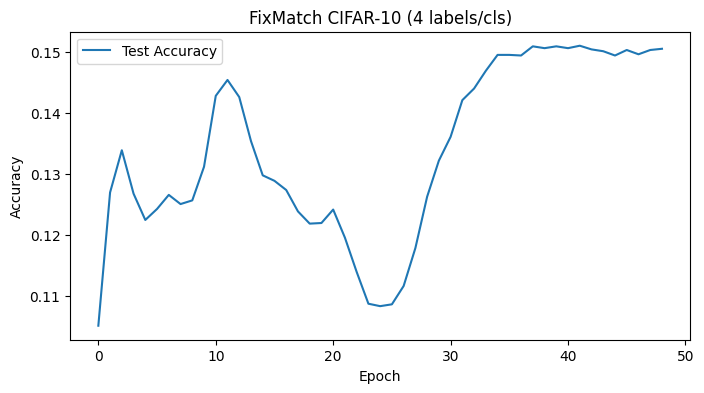

In [14]:
plt.figure(figsize=(8,4))
plt.plot(acc_hist, label='Test Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("FixMatch CIFAR-10 (4 labels/cls)")
plt.legend()
plt.show()


In [ ]:
# Exemplo: 25 rótulos por classe
qtd_epochs = 50

labeled_idx, unlabeled_idx = make_labeled_unlabeled_split(base_train, 25)

labeled_dataset = copy.deepcopy(base_train)
labeled_dataset.transform = weak_tf
labeled_subset = Subset(labeled_dataset, labeled_idx)

unlabeled_dataset = UnlabeledDataset(base_train, unlabeled_idx, weak_tf, strong_tf)

labeled_loader = DataLoader(labeled_subset, batch_size=64, shuffle=True, num_workers=2, drop_last=False)
unlabeled_loader = DataLoader(unlabeled_dataset, batch_size=320, shuffle=True, num_workers=2, drop_last=True)
test_loader = DataLoader(test_set, batch_size=256, shuffle=False, num_workers=2)


model = get_model(tipo = "resnet").to(device)
optimizer = optim.SGD(model.parameters(), lr=0.003, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=qtd_epochs)

train_loss_hist, acc_hist = [], []

for epoch in range(1, qtd_epochs):
    loss = train_fixmatch(model, device, labeled_loader, unlabeled_loader, optimizer, epoch, lambda_u=1.0, threshold=0.8)
    acc = evaluate(model, device, test_loader)
    scheduler.step()
    train_loss_hist.append(loss)
    acc_hist.append(acc)
    print(f"Epoch {epoch:03d} | Loss: {loss:.3f} | Test Acc: {acc*100:.2f}%")


Epoch 1: 100%|██████████| 4/4 [00:01<00:00,  2.75it/s]


Epoch 001 | Loss: 2.351 | Test Acc: 13.81%


Epoch 2: 100%|██████████| 4/4 [00:01<00:00,  2.84it/s]


Epoch 002 | Loss: 2.284 | Test Acc: 12.48%


Epoch 3: 100%|██████████| 4/4 [00:01<00:00,  2.82it/s]


...

Epoch 047 | Loss: 1.689 | Test Acc: 26.66%


Epoch 48: 100%|██████████| 4/4 [00:01<00:00,  2.83it/s]


Epoch 048 | Loss: 1.691 | Test Acc: 26.71%


Epoch 49: 100%|██████████| 4/4 [00:01<00:00,  2.78it/s]


Epoch 049 | Loss: 1.768 | Test Acc: 26.88%


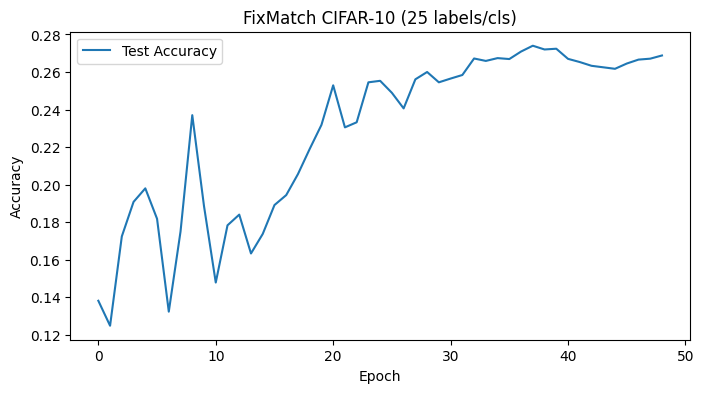

In [16]:
plt.figure(figsize=(8,4))
plt.plot(acc_hist, label='Test Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("FixMatch CIFAR-10 (25 labels/cls)")
plt.legend()
plt.show()


In [ ]:
# Exemplo: 400 rótulos por classe
qtd_epochs = 200

labeled_idx, unlabeled_idx = make_labeled_unlabeled_split(base_train, 400)

labeled_dataset = copy.deepcopy(base_train)
labeled_dataset.transform = weak_tf
labeled_subset = Subset(labeled_dataset, labeled_idx)

unlabeled_dataset = UnlabeledDataset(base_train, unlabeled_idx, weak_tf, strong_tf)

labeled_loader = DataLoader(labeled_subset, batch_size=64, shuffle=True, num_workers=2, drop_last=False)
unlabeled_loader = DataLoader(unlabeled_dataset, batch_size=320, shuffle=True, num_workers=2, drop_last=True)
test_loader = DataLoader(test_set, batch_size=256, shuffle=False, num_workers=2)


model = get_model(tipo = "resnet").to(device)
optimizer = optim.SGD(model.parameters(), lr=0.003, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=qtd_epochs)

train_loss_hist, acc_hist = [], []

for epoch in range(1, qtd_epochs):
    loss = train_fixmatch(model, device, labeled_loader, unlabeled_loader, optimizer, epoch, lambda_u=1.0, threshold=0.8)
    acc = evaluate(model, device, test_loader)
    scheduler.step()
    train_loss_hist.append(loss)
    acc_hist.append(acc)
    print(f"Epoch {epoch:03d} | Loss: {loss:.3f} | Test Acc: {acc*100:.2f}%")


Epoch 1: 100%|██████████| 63/63 [00:15<00:00,  3.96it/s]


Epoch 001 | Loss: 2.583 | Test Acc: 19.02%


Epoch 2: 100%|██████████| 63/63 [00:15<00:00,  4.01it/s]


Epoch 002 | Loss: 2.419 | Test Acc: 24.12%


Epoch 3: 100%|██████████| 63/63 [00:15<00:00,  4.00it/s]


...

Epoch 197 | Loss: 0.229 | Test Acc: 80.58%


Epoch 198: 100%|██████████| 63/63 [00:15<00:00,  4.04it/s]


Epoch 198 | Loss: 0.233 | Test Acc: 80.57%


Epoch 199: 100%|██████████| 63/63 [00:15<00:00,  4.04it/s]


Epoch 199 | Loss: 0.224 | Test Acc: 80.61%


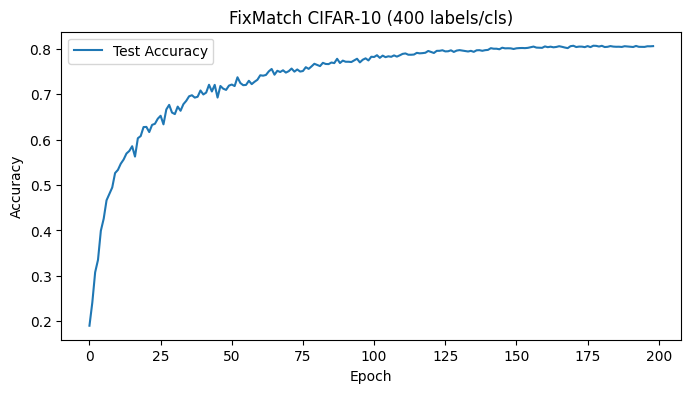

In [34]:
plt.figure(figsize=(8,4))
plt.plot(acc_hist, label='Test Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("FixMatch CIFAR-10 (400 labels/cls)")
plt.legend()
plt.show()



Acurácia por classe no conjunto de teste:
airplane  : 82.50%
automobile: 89.90%
bird      : 73.80%
cat       : 65.70%
deer      : 76.90%
dog       : 67.10%
frog      : 85.50%
horse     : 84.60%
ship      : 90.30%
truck     : 89.80%

Melhor classe: ship (90.30%)
Pior classe: cat (65.70%)


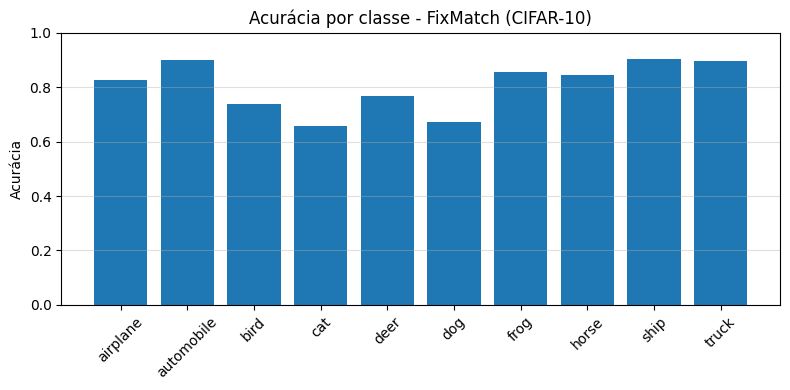

array([0.825, 0.899, 0.738, 0.657, 0.769, 0.671, 0.855, 0.846, 0.903,
       0.898])

In [35]:
# Performance do modelo em cada classe

# Classes do CIFAR-10
CIFAR10_CLASSES = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

def evaluate_per_class(model, device, test_loader, class_names=CIFAR10_CLASSES):
    model.eval()
    correct_per_class = np.zeros(len(class_names))
    total_per_class = np.zeros(len(class_names))

    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            preds = model(x).argmax(dim=1)
            for i in range(len(class_names)):
                mask = (y == i)
                correct_per_class[i] += (preds[mask] == y[mask]).sum().item()
                total_per_class[i] += mask.sum().item()

    acc_per_class = correct_per_class / total_per_class

    # Impressão dos resultados
    print("\nAcurácia por classe no conjunto de teste:")
    for i, acc in enumerate(acc_per_class):
        print(f"{class_names[i]:<10}: {acc*100:.2f}%")

    best_idx = np.argmax(acc_per_class)
    worst_idx = np.argmin(acc_per_class)

    print(f"\nMelhor classe: {class_names[best_idx]} ({acc_per_class[best_idx]*100:.2f}%)")
    print(f"Pior classe: {class_names[worst_idx]} ({acc_per_class[worst_idx]*100:.2f}%)")

    # Gráfico de barras
    plt.figure(figsize=(8, 4))
    plt.bar(class_names, acc_per_class)
    plt.title("Acurácia por classe - FixMatch (CIFAR-10)")
    plt.ylabel("Acurácia")
    plt.ylim(0, 1.0)
    plt.grid(axis='y', alpha=0.4)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig("fixmatch_per_class.png", dpi=300)
    plt.show()

    return acc_per_class

model.eval()
evaluate_per_class(model, device, test_loader)


## Treino com Wide ResNet

In [ ]:
# Exemplo: 1 rótulo por classe

qtd_epochs = 50
labeled_idx, unlabeled_idx = make_labeled_unlabeled_split(base_train, 1)

labeled_dataset = copy.deepcopy(base_train)
labeled_dataset.transform = weak_tf
labeled_subset = Subset(labeled_dataset, labeled_idx)

unlabeled_dataset = UnlabeledDataset(base_train, unlabeled_idx, weak_tf, strong_tf)

labeled_loader = DataLoader(labeled_subset, batch_size=64, shuffle=True, num_workers=2, drop_last=False)
unlabeled_loader = DataLoader(unlabeled_dataset, batch_size=320, shuffle=True, num_workers=2, drop_last=True)
test_loader = DataLoader(test_set, batch_size=256, shuffle=False, num_workers=2)


model = get_model(tipo = "WideResnet").to(device)
optimizer = optim.SGD(model.parameters(), lr=0.003, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=qtd_epochs)

train_loss_hist, acc_hist = [], []

for epoch in range(1, qtd_epochs):
    loss = train_fixmatch(model, device, labeled_loader, unlabeled_loader, optimizer, epoch, lambda_u=1.0, threshold=0.8)
    acc = evaluate(model, device, test_loader)
    scheduler.step()
    train_loss_hist.append(loss)
    acc_hist.append(acc)
    print(f"Epoch {epoch:03d} | Loss: {loss:.3f} | Test Acc: {acc*100:.2f}%")


Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Epoch 1: 100%|██████████| 1/1 [00:01<00:00,  1.66s/it]


Epoch 001 | Loss: 2.443 | Test Acc: 7.44%


Epoch 2: 100%|██████████| 1/1 [00:01<00:00,  1.65s/it]


Epoch 002 | Loss: 2.195 | Test Acc: 10.31%


Epoch 3: 100%|██████████| 1/1 [00:01<00:00,  1.66s/it]


...

Epoch 047 | Loss: 1.799 | Test Acc: 9.74%


Epoch 48: 100%|██████████| 1/1 [00:01<00:00,  1.68s/it]


Epoch 048 | Loss: 1.646 | Test Acc: 9.93%


Epoch 49: 100%|██████████| 1/1 [00:01<00:00,  1.69s/it]


Epoch 049 | Loss: 1.732 | Test Acc: 10.02%


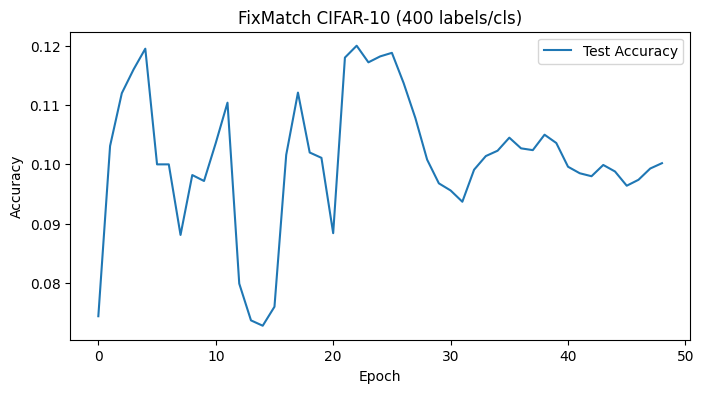

In [24]:
plt.figure(figsize=(8,4))
plt.plot(acc_hist, label='Test Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("FixMatch CIFAR-10 (400 labels/cls)")
plt.legend()
plt.show()

In [ ]:
# Exemplo: 4 rótulo por classe

qtd_epochs = 50
labeled_idx, unlabeled_idx = make_labeled_unlabeled_split(base_train, 4)

labeled_dataset = copy.deepcopy(base_train)
labeled_dataset.transform = weak_tf
labeled_subset = Subset(labeled_dataset, labeled_idx)

unlabeled_dataset = UnlabeledDataset(base_train, unlabeled_idx, weak_tf, strong_tf)

labeled_loader = DataLoader(labeled_subset, batch_size=64, shuffle=True, num_workers=2, drop_last=False)
unlabeled_loader = DataLoader(unlabeled_dataset, batch_size=320, shuffle=True, num_workers=2, drop_last=True)
test_loader = DataLoader(test_set, batch_size=256, shuffle=False, num_workers=2)


model = get_model(tipo = "WideResnet").to(device)
optimizer = optim.SGD(model.parameters(), lr=0.003, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=qtd_epochs)

train_loss_hist, acc_hist = [], []

for epoch in range(1, qtd_epochs):
    loss = train_fixmatch(model, device, labeled_loader, unlabeled_loader, optimizer, epoch, lambda_u=1.0, threshold=0.8)
    acc = evaluate(model, device, test_loader)
    scheduler.step()
    train_loss_hist.append(loss)
    acc_hist.append(acc)
    print(f"Epoch {epoch:03d} | Loss: {loss:.3f} | Test Acc: {acc*100:.2f}%")


Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Epoch 1: 100%|██████████| 1/1 [00:01<00:00,  1.78s/it]


Epoch 001 | Loss: 2.434 | Test Acc: 9.55%


Epoch 2: 100%|██████████| 1/1 [00:01<00:00,  1.77s/it]


Epoch 002 | Loss: 2.308 | Test Acc: 9.97%


Epoch 3: 100%|██████████| 1/1 [00:01<00:00,  1.74s/it]


...

Epoch 047 | Loss: 2.517 | Test Acc: 14.60%


Epoch 48: 100%|██████████| 1/1 [00:01<00:00,  1.75s/it]


Epoch 048 | Loss: 2.631 | Test Acc: 14.68%


Epoch 49: 100%|██████████| 1/1 [00:01<00:00,  1.75s/it]


Epoch 049 | Loss: 2.360 | Test Acc: 14.73%


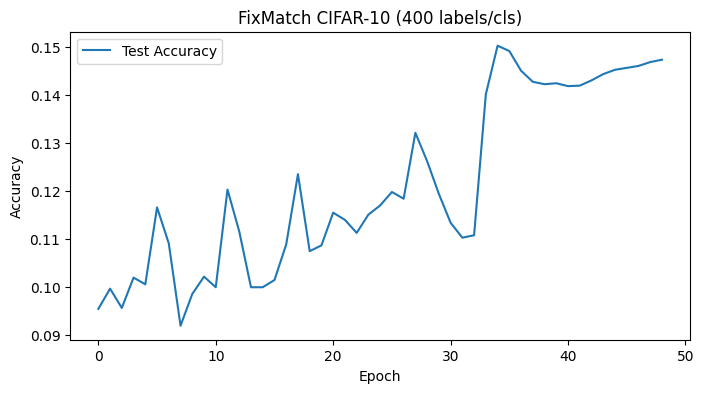

In [27]:
plt.figure(figsize=(8,4))
plt.plot(acc_hist, label='Test Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("FixMatch CIFAR-10 (400 labels/cls)")
plt.legend()
plt.show()

In [ ]:
# Exemplo: 25 rótulo por classe

qtd_epochs = 50
labeled_idx, unlabeled_idx = make_labeled_unlabeled_split(base_train, 25)

labeled_dataset = copy.deepcopy(base_train)
labeled_dataset.transform = weak_tf
labeled_subset = Subset(labeled_dataset, labeled_idx)

unlabeled_dataset = UnlabeledDataset(base_train, unlabeled_idx, weak_tf, strong_tf)

labeled_loader = DataLoader(labeled_subset, batch_size=64, shuffle=True, num_workers=2, drop_last=False)
unlabeled_loader = DataLoader(unlabeled_dataset, batch_size=320, shuffle=True, num_workers=2, drop_last=True)
test_loader = DataLoader(test_set, batch_size=256, shuffle=False, num_workers=2)


model = get_model(tipo = "WideResnet").to(device)
optimizer = optim.SGD(model.parameters(), lr=0.003, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=qtd_epochs)

train_loss_hist, acc_hist = [], []

for epoch in range(1, qtd_epochs):
    loss = train_fixmatch(model, device, labeled_loader, unlabeled_loader, optimizer, epoch, lambda_u=1.0, threshold=0.8)
    acc = evaluate(model, device, test_loader)
    scheduler.step()
    train_loss_hist.append(loss)
    acc_hist.append(acc)
    print(f"Epoch {epoch:03d} | Loss: {loss:.3f} | Test Acc: {acc*100:.2f}%")


Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Epoch 1: 100%|██████████| 4/4 [00:06<00:00,  1.50s/it]


Epoch 001 | Loss: 2.459 | Test Acc: 10.00%


Epoch 2: 100%|██████████| 4/4 [00:05<00:00,  1.50s/it]


Epoch 002 | Loss: 4.220 | Test Acc: 16.12%


Epoch 3: 100%|██████████| 4/4 [00:06<00:00,  1.50s/it]


...

Epoch 047 | Loss: 2.473 | Test Acc: 19.46%


Epoch 48: 100%|██████████| 4/4 [00:05<00:00,  1.47s/it]


Epoch 048 | Loss: 2.632 | Test Acc: 19.45%


Epoch 49: 100%|██████████| 4/4 [00:05<00:00,  1.47s/it]


Epoch 049 | Loss: 2.503 | Test Acc: 19.53%


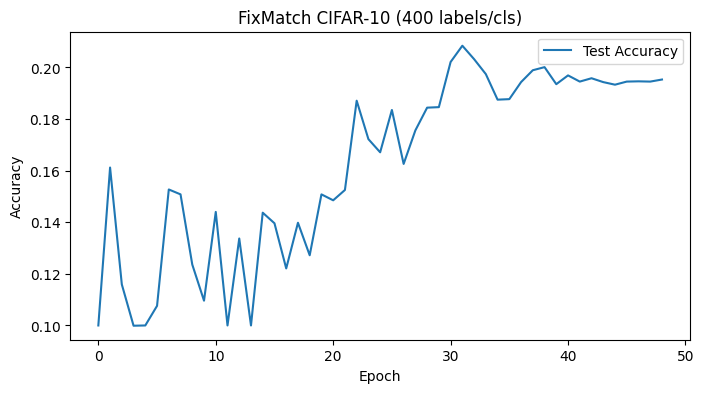

In [29]:
plt.figure(figsize=(8,4))
plt.plot(acc_hist, label='Test Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("FixMatch CIFAR-10 (400 labels/cls)")
plt.legend()
plt.show()

In [ ]:
# Exemplo: 400 rótulo por classe

qtd_epochs = 50
labeled_idx, unlabeled_idx = make_labeled_unlabeled_split(base_train, 400)

labeled_dataset = copy.deepcopy(base_train)
labeled_dataset.transform = weak_tf
labeled_subset = Subset(labeled_dataset, labeled_idx)

unlabeled_dataset = UnlabeledDataset(base_train, unlabeled_idx, weak_tf, strong_tf)

labeled_loader = DataLoader(labeled_subset, batch_size=64, shuffle=True, num_workers=2, drop_last=False)
unlabeled_loader = DataLoader(unlabeled_dataset, batch_size=320, shuffle=True, num_workers=2, drop_last=True)
test_loader = DataLoader(test_set, batch_size=256, shuffle=False, num_workers=2)


model = get_model(tipo = "WideResnet").to(device)
optimizer = optim.SGD(model.parameters(), lr=0.003, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=qtd_epochs)

train_loss_hist, acc_hist = [], []

for epoch in range(1, qtd_epochs):
    loss = train_fixmatch(model, device, labeled_loader, unlabeled_loader, optimizer, epoch, lambda_u=1.0, threshold=0.8)
    acc = evaluate(model, device, test_loader)
    scheduler.step()
    train_loss_hist.append(loss)
    acc_hist.append(acc)
    print(f"Epoch {epoch:03d} | Loss: {loss:.3f} | Test Acc: {acc*100:.2f}%")


Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Epoch 1: 100%|██████████| 63/63 [01:25<00:00,  1.36s/it]


Epoch 001 | Loss: 4.938 | Test Acc: 10.00%


Epoch 2: 100%|██████████| 63/63 [01:25<00:00,  1.36s/it]


Epoch 002 | Loss: 4.363 | Test Acc: 13.12%


Epoch 3: 100%|██████████| 63/63 [01:25<00:00,  1.36s/it]


...

Epoch 047 | Loss: 0.959 | Test Acc: 62.56%


Epoch 48: 100%|██████████| 63/63 [01:25<00:00,  1.36s/it]


Epoch 048 | Loss: 0.959 | Test Acc: 62.73%


Epoch 49: 100%|██████████| 63/63 [01:25<00:00,  1.36s/it]


Epoch 049 | Loss: 0.958 | Test Acc: 62.76%


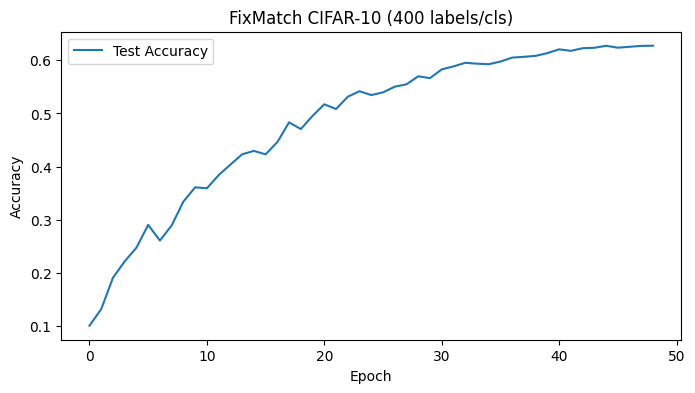

In [31]:
plt.figure(figsize=(8,4))
plt.plot(acc_hist, label='Test Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("FixMatch CIFAR-10 (400 labels/cls)")
plt.legend()
plt.show()


Acurácia por classe no conjunto de teste:
airplane  : 63.70%
automobile: 79.90%
bird      : 40.50%
cat       : 33.40%
deer      : 53.30%
dog       : 59.40%
frog      : 76.80%
horse     : 63.50%
ship      : 76.90%
truck     : 80.20%

Melhor classe: truck (80.20%)
Pior classe: cat (33.40%)


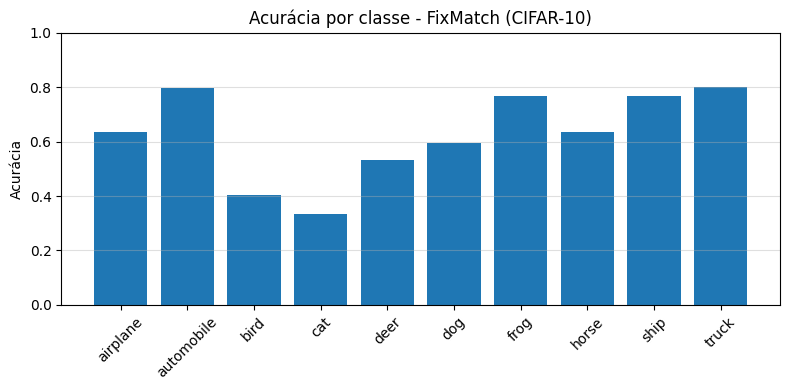

array([0.637, 0.799, 0.405, 0.334, 0.533, 0.594, 0.768, 0.635, 0.769,
       0.802])

In [32]:
# Performance do modelo em cada classe

# Classes do CIFAR-10
CIFAR10_CLASSES = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

def evaluate_per_class(model, device, test_loader, class_names=CIFAR10_CLASSES):
    model.eval()
    correct_per_class = np.zeros(len(class_names))
    total_per_class = np.zeros(len(class_names))

    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            preds = model(x).argmax(dim=1)
            for i in range(len(class_names)):
                mask = (y == i)
                correct_per_class[i] += (preds[mask] == y[mask]).sum().item()
                total_per_class[i] += mask.sum().item()

    acc_per_class = correct_per_class / total_per_class

    # Impressão dos resultados
    print("\nAcurácia por classe no conjunto de teste:")
    for i, acc in enumerate(acc_per_class):
        print(f"{class_names[i]:<10}: {acc*100:.2f}%")

    best_idx = np.argmax(acc_per_class)
    worst_idx = np.argmin(acc_per_class)

    print(f"\nMelhor classe: {class_names[best_idx]} ({acc_per_class[best_idx]*100:.2f}%)")
    print(f"Pior classe: {class_names[worst_idx]} ({acc_per_class[worst_idx]*100:.2f}%)")

    # Gráfico de barras
    plt.figure(figsize=(8, 4))
    plt.bar(class_names, acc_per_class)
    plt.title("Acurácia por classe - FixMatch (CIFAR-10)")
    plt.ylabel("Acurácia")
    plt.ylim(0, 1.0)
    plt.grid(axis='y', alpha=0.4)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig("fixmatch_per_class.png", dpi=300)
    plt.show()

    return acc_per_class

model.eval()
evaluate_per_class(model, device, test_loader)